### Insurance_analysis

in this notebook we will analyis, visulaize and predict the insurance for any indivisual

#### First we will import all the requirements

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


##### Here's the cleaning function

In [10]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    # Dropping NA
    df = df.dropna()

    
    #Floating any data
    df = df.astype({'bmi': float, 'children': float, 'charges': float})

    # # Renaming the categorical variable
    df['sex'] = df['sex'].replace('male', '1')
    df['sex'] = df['sex'].replace('female', '0')

    df['smoker'] = df['smoker'].replace('yes', '1')
    df['smoker'] = df['smoker'].replace('no', '0')

    df = df.astype({'bmi': float, 'children': float, 'charges': float, 'smoker': int, 'sex': int})

    df = pd.concat([df, pd.get_dummies(df['region'], dtype=int)], axis=1)
    df = df.rename(columns={'sex': 'is_male', 'smoker': 'is_smoker'})

    return df
    

##### Now cleaning time

In [20]:
df = pd.read_csv('../data/insurance.csv')
df = clean_data(df)
df.head()

,age,is_male,bmi,children,is_smoker,region,charges,northeast,northwest,southeast,southwest
0,19,0,27.900,0.0,1,southwest,16884.92400,0,0,0,1
1,18,1,33.770,1.0,0,southeast,1725.55230,0,0,1,0
2,28,1,33.000,3.0,0,southeast,4449.46200,0,0,1,0
3,33,1,22.705,0.0,0,northwest,21984.47061,0,1,0,0
4,32,1,28.880,0.0,0,northwest,3866.85520,0,1,0,0


#### Visualizing the relationship between each feature and charges (our dependent variable)

<Axes: xlabel='age', ylabel='charges'>

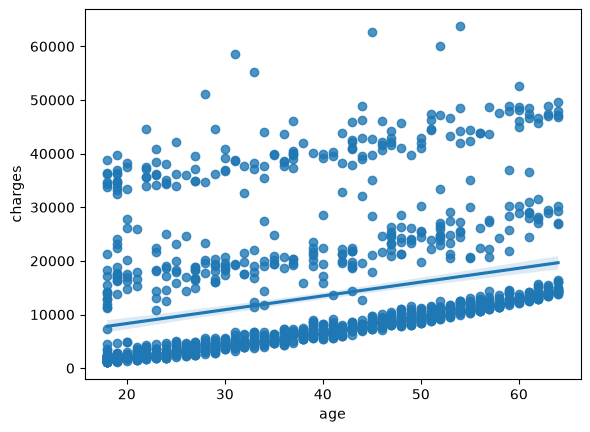

In [36]:

sns.regplot(df, x='age', y='charges')

<Axes: xlabel='is_smoker', ylabel='charges'>

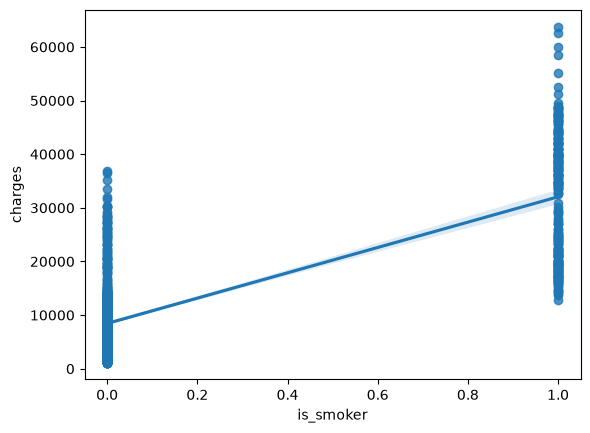

In [37]:
sns.regplot(df, x='is_smoker', y='charges')

<Axes: xlabel='bmi', ylabel='charges'>

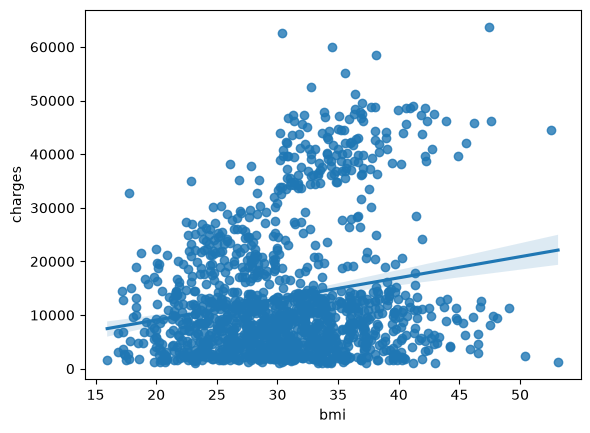

In [38]:
sns.regplot(df, x='bmi', y='charges')

##### We can see that age, smoking and bmi will be the best independent variables in this case, we will build a simple model function that uses linear regression and histplot to visualize the relationship

In [50]:
def simple_model(df: pd.DataFrame, feature: str):
    X = df[[feature]]
    Y = df['charges']

    lm = LinearRegression()

    lm.fit(X, Y)

    yHat = lm.predict(X)

    ax1 = sns.histplot(Y, color='b', label='Actual', kde=True)
    sns.histplot(yHat, color='r', label='Predicted', ax=ax1, kde=True)
    plt.legend()
    plt.show()
    return yHat

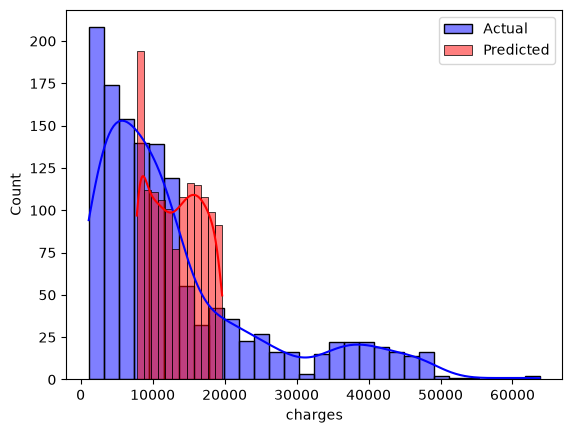

array([ 8062.61476073,  7804.89214207, 10382.11832874, ...,
        7804.89214207,  8578.05999807, 18886.96474474], shape=(1338,))

In [51]:
## Call it with age
simple_model(df, 'age')

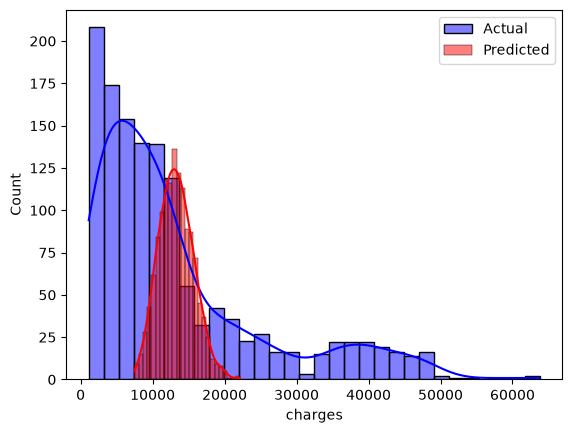

In [48]:
## Call it with bmi
simple_model(df, 'bmi')

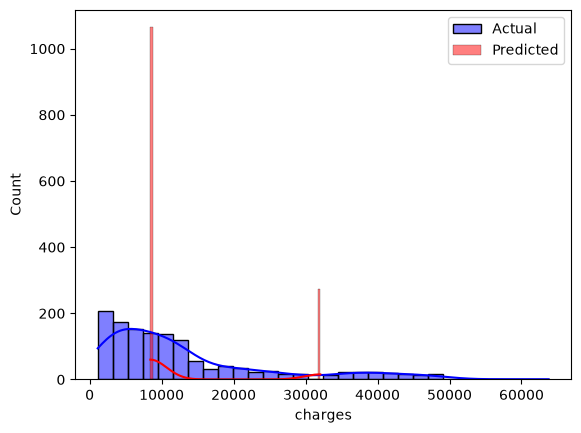

array([32050.23183153,  8434.26829786,  8434.26829786, ...,
        8434.26829786,  8434.26829786, 32050.23183153], shape=(1338,))

In [52]:
## Call it with smoking
simple_model(df, 'is_smoker')

#### As you notice, picking a single feature might not be the best approach for this case. We will have to make a new model that takes multiple feature

In [57]:
def multi_feature_model(df: pd.DataFrame, features: list):
    X = df[features]
    Y = df['charges']
    lm = LinearRegression()
    lm.fit(X, Y)
    
    yHat = lm.predict(X=X)

    ax1 = sns.histplot(Y, color='b', label='Actual', kde=True)
    sns.histplot(yHat, color='r', label='Predicted', kde=True, ax=ax1)

    plt.legend()
    plt.show()

    return yHat

##### Now, we will call our function passing the dataframe and ['age', 'is_smoker', 'bmi'] as the independent variables

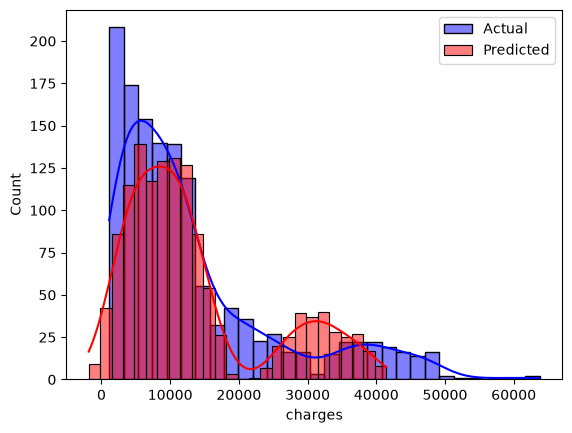

In [65]:
yHat_small = multi_feature_model(df, ['age', 'is_smoker', 'bmi'])

##### As we can notice, this model is much better, can we even improve on it more by adding all the other variables too ?

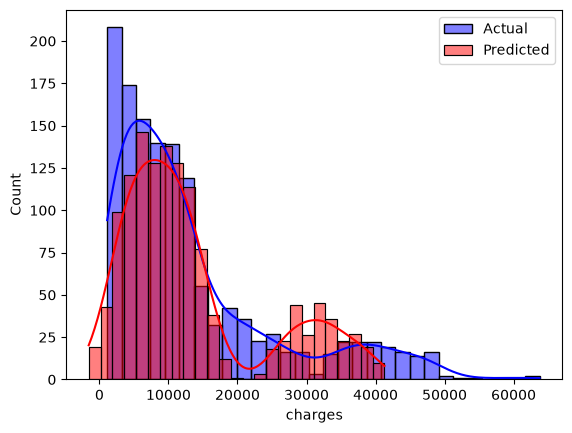

In [64]:
yHat_big = multi_feature_model(df, ['age', 'is_smoker', 'bmi', 'northeast', 'northwest', 'southeast', 'southwest'])

##### We can notice that both of them are pretty close, we will compare their R^2 to know which one is better

In [68]:
y = df['charges']
r2_first = r2_score(y, yHat_small)
r2_second = r2_score(y, yHat_big)
print('R^2 of the first one: ', r2_first)
print('R^2 of the second one: ', r2_second)

R^2 of the first one:  0.7474771588119513
R^2 of the second one:  0.7486604464800043


##### Now let's also compare the MSE (Less is better)

In [69]:
mse_first = mean_squared_error(y, yHat_small)
mse_second = mean_squared_error(y, yHat_big)

print('MSE of the fist one', mse_first)
print('MSE of the second one', mse_second)

MSE of the fist one 37005395.75050751
MSE of the second one 36831993.502073325


##### So far, we can see that the second model with more features is better, however, we never actually evaluated the model on a data it never saw before, so we will split our dataframe.

In [72]:
def split_data(df: pd.DataFrame, x: list, y: str):
    x_train, x_test = df[x][:500], df[x][500:]
    y_train, y_test = df[y][:500], df[y][500:]

    return x_train, x_test, y_train, y_test

x_train, x_test, y_train, y_test = split_data(df, ['age', 'is_smoker', 'bmi', 'northeast', 'northwest', 'southeast', 'southwest'], 'charges')


#### We will modify our model function so it works with our new approach

In [75]:
def multi_feature_model(X, Y, Xtest, Ytest):
    lm = LinearRegression()
    lm.fit(X, Y)
    
    yHat = lm.predict(X=Xtest)

    ax1 = sns.histplot(Ytest, color='b', label='Actual', kde=True)
    sns.histplot(yHat, color='r', label='Predicted', kde=True, ax=ax1)

    plt.legend()
    plt.show()

    return yHat

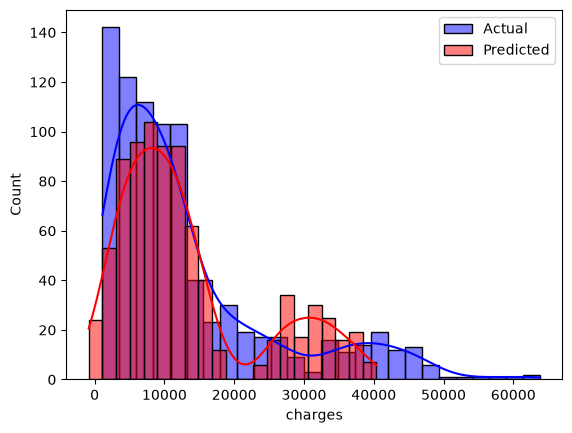

In [77]:
yHat = multi_feature_model(x_train, y_train, x_test, y_test)